In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

import sim_ranking as sr
import ml_tools as mlt


In [2]:
emp_cim_dir = Path("/Users/claudy/dev/work/data/sim_ranking/results/20240301_comparison/synthethic/emp_cIM_perturbed_100r")
ml_data_dir = Path("/Users/claudy/dev/work/data/sim_ranking/results/20240301_comparison/synthethic/0423_1449_lb_30_100_SCweighted_probL2_0p5")

db_ffp = Path("/Users/claudy/dev/work/data/sim_ranking/emp_realisations/perturbed_0313_100r/gm_db_emp.sqlite")

In [3]:
def load_cim_data(data_dir: Path, event: str):
	result_ffp = data_dir / event / "empirical_cMVN/cMVN_distributions.pickle"
	return sr.conditional.ConditionalMVNDistribution.load(result_ffp)


In [4]:
meta = mlt.utils.load_yaml(ml_data_dir / "meta.yaml")
run_config = sr.ml.sc_prob.RunParamsConfig.from_dict(meta["run_config"])

val_sc_sum_df = pd.read_parquet(ml_data_dir / "val_scenario_summary.parquet")
val_sc_df = pd.read_parquet(ml_data_dir / "val_scenario_results.parquet")

db = sr.db.DB(db_ffp)

In [5]:
meta = mlt.utils.load_yaml(ml_data_dir / "meta.yaml")
run_config = sr.ml.sc_prob.RunParamsConfig.from_dict(meta["run_config"])

im_wavg_cols = mlt.array_utils.numpy_str_join("_", run_config.ims, "wavg")
im_wstd_cols = mlt.array_utils.numpy_str_join("_", run_config.ims, "wstd")

In [6]:
cur_event = "2013p750727"

In [7]:
cur_emp_cim = load_cim_data(emp_cim_dir, cur_event)

cur_sc_sum_df = val_sc_sum_df[val_sc_sum_df["event_id"] == cur_event].set_index("site_int").sort_index()
cur_sites = cur_sc_sum_df.index.values.astype(str)

# Mean residual
cur_ml_mean_df = cur_sc_sum_df[im_wavg_cols]
cur_emp_cim_mean_df = cur_emp_cim.cond_lnIM_mean_df.loc[cur_sites, run_config.ims]
assert np.all(cur_ml_mean_df.index == cur_emp_cim_mean_df.index)

cur_mean_residuals = pd.DataFrame(data=cur_emp_cim_mean_df[run_config.ims].values - cur_ml_mean_df[im_wavg_cols].values, index=cur_sites, columns=run_config.ims)

# Std residual
cur_ml_std_df = cur_sc_sum_df[im_wstd_cols]
cur_emp_cim_std_df = cur_emp_cim.cond_lnIM_std_df.loc[cur_sites, run_config.ims]
assert np.all(cur_ml_std_df.index == cur_emp_cim_std_df.index)

cur_std_residuals = pd.DataFrame(data=cur_emp_cim_std_df[run_config.ims].values - cur_ml_std_df[im_wstd_cols].values, index=cur_sites, columns=run_config.ims)


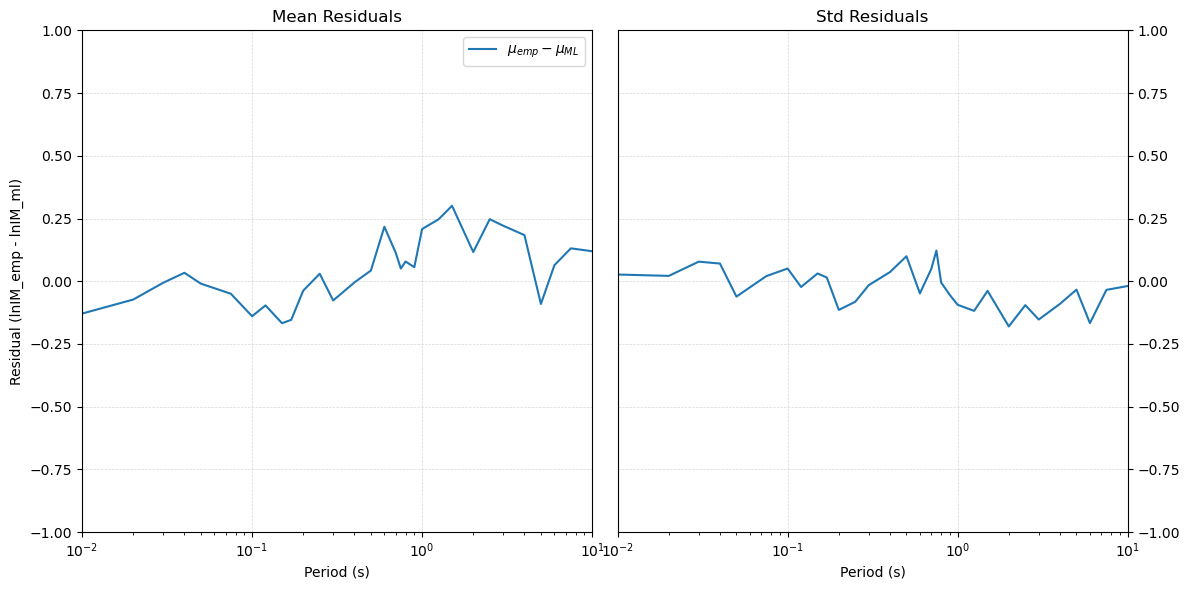

In [8]:
# Single event & site
cur_site_int = "ARKS"

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 6))

# Mean
ax1.semilogx(sr.constants.PERIODS, cur_mean_residuals.loc[cur_site_int, sr.constants.PSA_KEYS].values, label="$\mu_{emp} - \mu_{ML}$")

ax1.set_title(f"Mean Residuals")
ax1.set_xlabel(f"Period (s)")
ax1.set_ylabel(f"Residual (lnIM_emp - lnIM_ml)")
ax1.grid(linewidth=0.5, alpha=0.5, linestyle="--")

ax1.set_xlim(0.01, 10)
ax1.set_ylim(-1, 1)

ax1.legend()

# Std
ax2.semilogx(sr.constants.PERIODS, cur_std_residuals.loc[cur_site_int, sr.constants.PSA_KEYS].values, label="$\sigma_{emp} - \sigma_{ML}$")

ax2.set_title(f"Std Residuals")
ax2.set_xlabel(f"Period (s)")
ax2.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax2.yaxis.tick_right()

ax2.set_xlim(0.01, 10)
ax2.set_ylim(-1, 1)

fig.tight_layout()
fig.subplots_adjust(wspace=0.05)

In [9]:
# Get all residuals
mean_residual, std_residuals = sr.ml.sc_prob.compute_mean_std_residuals_wrt_emp(val_sc_sum_df, emp_cim_dir, run_config)

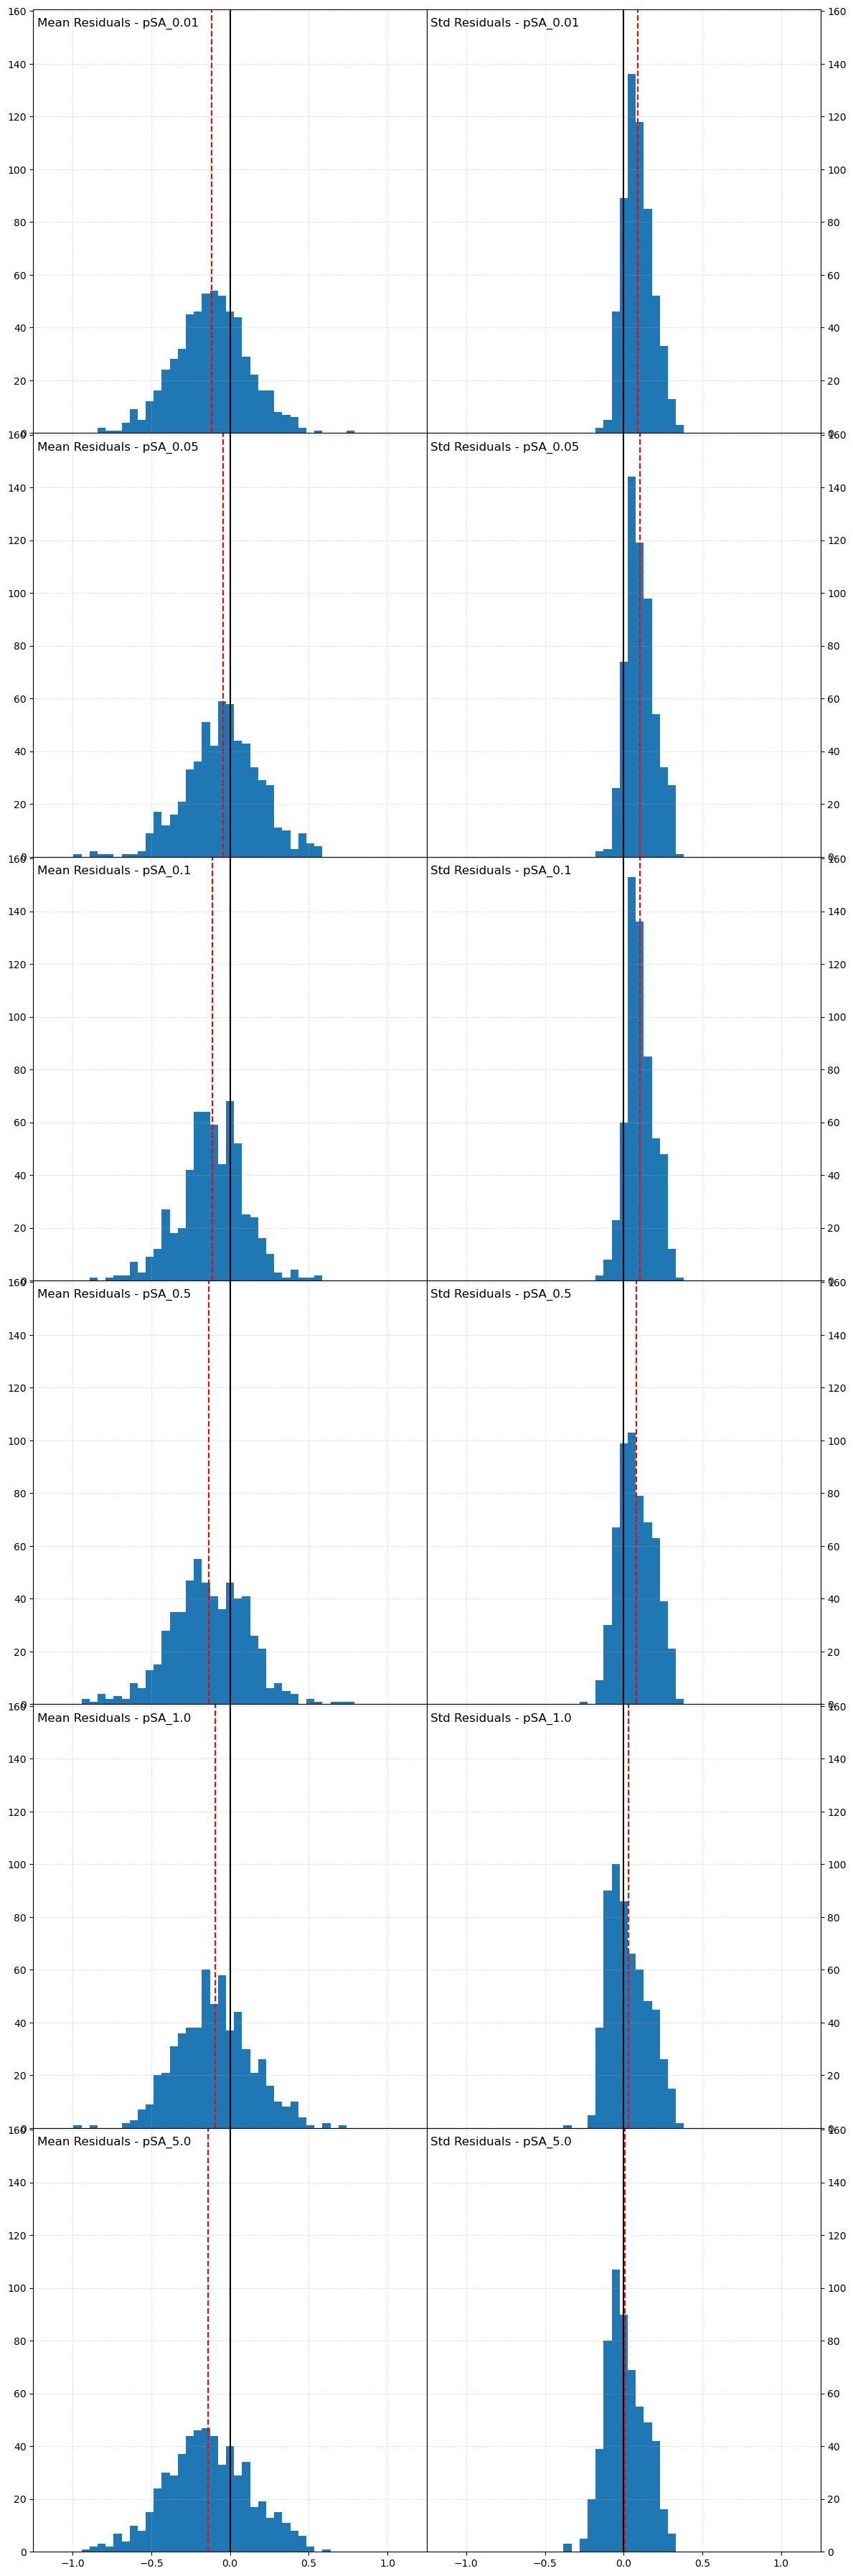

In [42]:
ims = ["pSA_0.01", "pSA_0.05", "pSA_0.1", "pSA_0.5", "pSA_1.0", "pSA_5.0"]

n_ims = len(ims)
n_rows = n_ims

fig, axs = plt.subplots(n_rows, 2, figsize=(12, n_rows * 6), sharex=True)

bins = np.linspace(-1.25, 1.25, 50)

y_max = 0
for ix, (cur_im, (cur_ax1, cur_ax2)) in enumerate(zip(ims, axs)):
	cur_ax1.hist(mean_residual[cur_im].values, bins=bins)
	cur_ax1.axvline(np.mean(mean_residual[cur_im].values), color="r", linestyle="--")
	cur_ax1.axvline(0, color="k", linestyle="-")
	cur_ax1.grid(linewidth=0.5, alpha=0.5, linestyle="--")
	
	cur_ax2.hist(std_residuals[cur_im].values, bins=bins)
	cur_ax2.axvline(np.mean(std_residuals[cur_im].values), color="r", linestyle="--")
	cur_ax2.axvline(0, color="k", linestyle="-")
	cur_ax2.grid(linewidth=0.5, alpha=0.5, linestyle="--")
	
	if ix == 0: 
		cur_ax1.set_xlim(-1.25, 1.25)
	
	y_max = max(y_max, cur_ax1.get_ylim()[1], cur_ax2.get_ylim()[1]) 
	
	cur_ax2.yaxis.tick_right()
    
	cur_ax1.text(
	    0.01,
	    0.98,
	    f"Mean Residuals - {cur_im}",
	    horizontalalignment="left",
	    verticalalignment="top",
	    transform=cur_ax1.transAxes,
	    fontsize=12,
	)
	
	cur_ax2.text(
	    0.01,
	    0.98,
	    f"Std Residuals - {cur_im}",
	    horizontalalignment="left",
	    verticalalignment="top",
	    transform=cur_ax2.transAxes,
	    fontsize=12,
	)
	
    
for cur_ax in axs.ravel():
	cur_ax.set_ylim(0, y_max)

fig.tight_layout()
fig.subplots_adjust(wspace=0, hspace=0)